In [1]:
import pandas as pd 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier




In [2]:
titanic_data= pd.read_csv("titanic_data_modelready.csv")
print(titanic_data.head())
print(titanic_data.info())
print(titanic_data.describe())


   Survived  Sex   Age  SibSp  Parch     Fare  Embarked_Q  Embarked_S  \
0         0    0  22.0      1      0   7.2500       False        True   
1         1    1  38.0      1      0  71.2833       False       False   
2         1    1  26.0      0      0   7.9250       False        True   
3         1    1  35.0      1      0  53.1000       False        True   
4         0    0  35.0      0      0   8.0500       False        True   

   Pclass_2  Pclass_3  
0     False      True  
1     False     False  
2     False      True  
3     False     False  
4     False      True  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Sex         891 non-null    int64  
 2   Age         891 non-null    float64
 3   SibSp       891 non-null    int64  
 4   Parch       891 non-null    int64  
 5   Fare        891 non-

In [3]:
data = titanic_data[['Survived','Sex', 'Age','SibSp', 'Parch','Fare','Embarked_Q','Embarked_S','Pclass_2','Pclass_3']]

In [4]:
# X = data[['Pclass_2', 'Pclass_3','Sex' , 'Age' ,'Fare' ,'SibSp', 'Parch','Embarked_Q','Embarked_S']]
# Y= data[['Survived']]
X = data.drop(columns=["Survived"])
y = data["Survived"]


In [5]:
X_train , X_test , y_train , y_test = train_test_split(X , y ,test_size=0.3 , random_state=42)

In [6]:
# LogisticRegression
pipe_lr = Pipeline([
    ('scaler' , StandardScaler()),
    ('classifier' , LogisticRegression())
    
])
# DecisionTree
pipe_dt = Pipeline([
    ('scaler' , StandardScaler()),
    ('classifier' , DecisionTreeClassifier( random_state=42))
    
])

# RandomForest
pipe_rf = Pipeline([
    ('scaler' , StandardScaler()),
    ('classifier' , RandomForestClassifier(random_state=42))
    
])

In [7]:
pipelines = [pipe_lr, pipe_dt , pipe_rf]
model_name = {0 : 'LogisticRegression' , 1 : 'DecisionTree' , 2: 'RandomForest'}
best_accuracy = 0 
best_model= None

for i , model in enumerate(pipelines):
    model.fit(X_train , y_train)
    score = model.score(X_test , y_test)
    print(f"{model_name[i]} Test accuracy:{score:.3f}")

    if score > best_accuracy:
        best_accuracy = score
        best_model = model_name[i]
print(f"\n best model : {best_model} , with accuracy: {round(best_accuracy , 3)}")

LogisticRegression Test accuracy:0.806
DecisionTree Test accuracy:0.750
RandomForest Test accuracy:0.791

 best model : LogisticRegression , with accuracy: 0.806


In [8]:
from sklearn.model_selection import cross_val_score

for i, model in enumerate(pipelines):
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")
    print(f"{model_name[i]} CV accuracy: {scores.mean():.3f}")


LogisticRegression CV accuracy: 0.804
DecisionTree CV accuracy: 0.761
RandomForest CV accuracy: 0.803


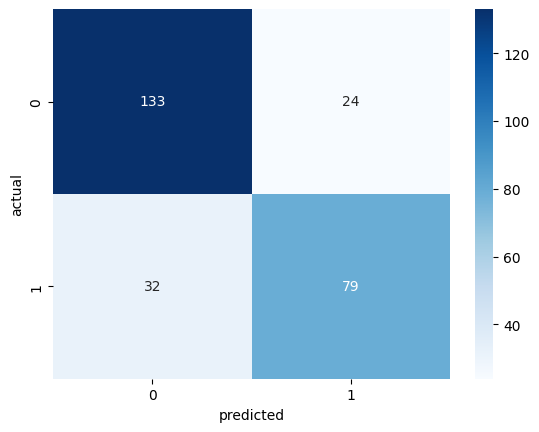

In [9]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns 


y_pred = model.predict(X_test)
cm= confusion_matrix(y_test , y_pred)

sns.heatmap(cm , annot=True  , fmt= 'd' , cmap= 'Blues')
plt.xlabel("predicted")
plt.ylabel("actual")
plt.show()